In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('test_data.csv')

In [5]:
df.head()

,Acceleration
0,-811.0
1,-846.0
2,-997.0
3,-1036.0
4,-978.0


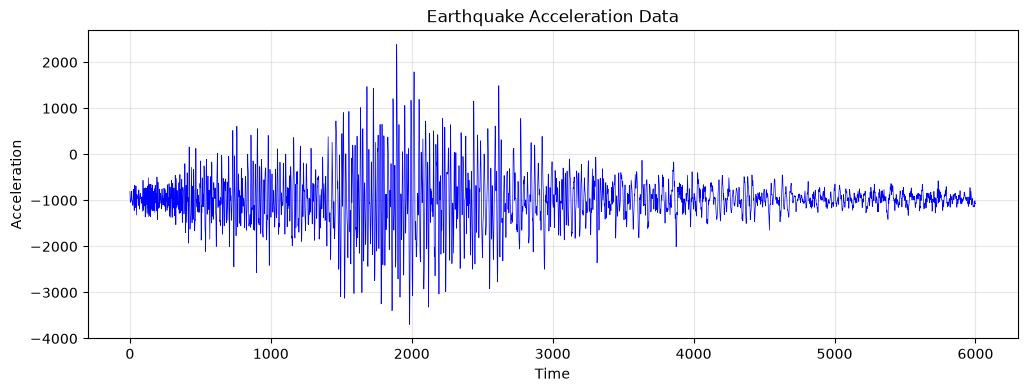

In [6]:
plt.figure(figsize = (12,4))

plt.plot(df["Acceleration"],color = "blue", linewidth = 0.5)
plt.title("Earthquake Acceleration Data")
plt.xlabel("Time")
plt.ylabel("Acceleration")
plt.grid(True,alpha = 0.3)

In [7]:
avg_data = df["Acceleration"].mean()
avg_data 

np.float64(-970.3758333333334)

In [8]:
df["Acceleration"] = df["Acceleration"] - avg_data

In [9]:
df.head()

,Acceleration
0,159.375833
1,124.375833
2,-26.624167
3,-65.624167
4,-7.624167


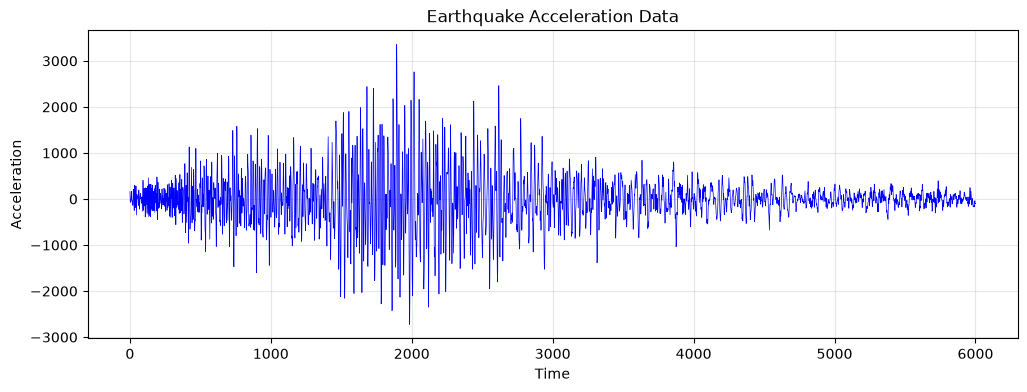

In [10]:
plt.figure(figsize = (12,4))

plt.plot(df["Acceleration"],color = "blue", linewidth = 0.5)
plt.title("Earthquake Acceleration Data")
plt.xlabel("Time")
plt.ylabel("Acceleration")
plt.grid(True,alpha = 0.3)

In [11]:
std = df["Acceleration"].std().item()

In [12]:
df["Acceleration"]= df["Acceleration"]/std

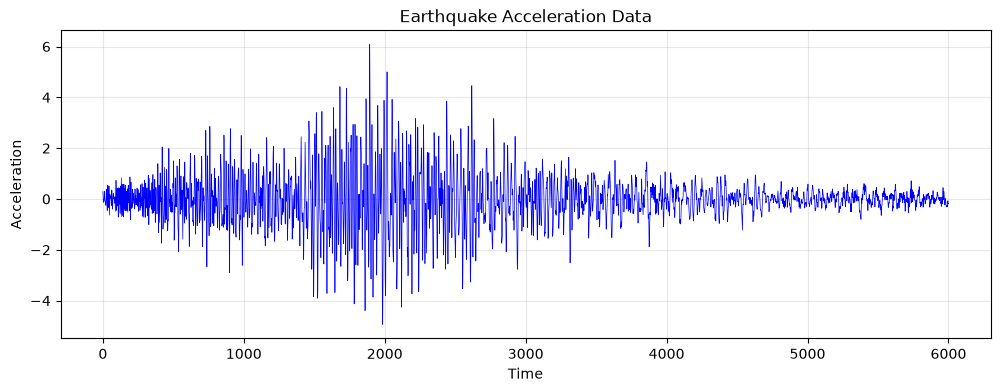

In [13]:
plt.figure(figsize = (12,4))

plt.plot(df["Acceleration"],color = "blue", linewidth = 0.5)
plt.title("Earthquake Acceleration Data")
plt.xlabel("Time")
plt.ylabel("Acceleration")
plt.grid(True,alpha = 0.3)

In [14]:
from scipy.signal import butter, filtfilt

def apply_butterworth(data, cutoff_freq, sample_rate, order=4):
    # Calculate the Nyquist frequency (half the sample rate)
    nyquist = 0.5 * sample_rate
    # Normalize the cutoff frequency for the algorithm
    normal_cutoff = cutoff_freq / nyquist
    
    # Generate the filter coefficients
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    
    # Apply the filter using filtfilt (this prevents the wave from shifting left/right)
    filtered_data = filtfilt(b, a, data)
    return filtered_data

In [15]:
#We assume the frequency of the earthquake data is 100 Hz (i.e., 100 samples per second)

df["Filtered_Acceleration"] = apply_butterworth(df["Acceleration"], cutoff_freq=20, sample_rate=100)

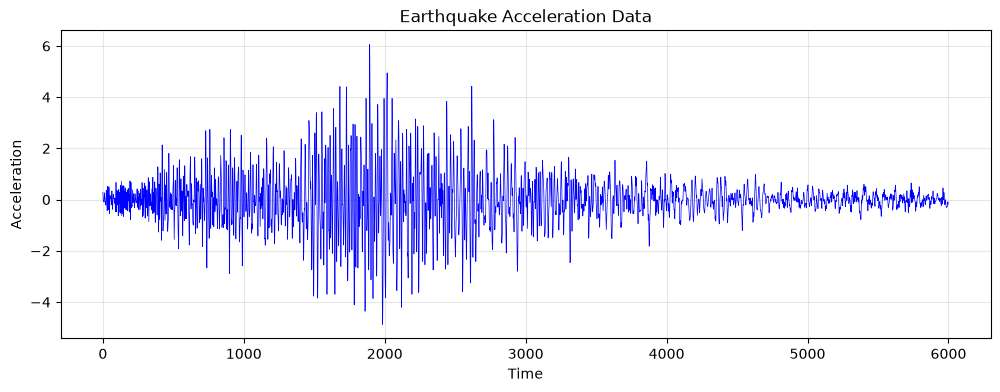

In [16]:
plt.figure(figsize = (12,4))

plt.plot(df["Filtered_Acceleration"],color = "blue", linewidth = 0.5)
plt.title("Earthquake Acceleration Data")
plt.xlabel("Time")
plt.ylabel("Acceleration")
plt.grid(True,alpha = 0.3)

In [17]:
Absolute_Filtered_Acceleration= df["Filtered_Acceleration"].abs()
STA = Absolute_Filtered_Acceleration.rolling(window=200 , min_periods=1).mean()
LTA = Absolute_Filtered_Acceleration.rolling(window=2000, min_periods=1).mean()
df["STA_LTA"] = STA / LTA